In [25]:
# Build the Real URL-Based Model

In [2]:
# Create Our Own URL Feature Extractor

In [3]:
import pandas as pd
import numpy as np
import re

from urllib.parse import urlparse

In [17]:
df = pd.read_csv("../data/PhiUSIIL_Phishing_URL_Dataset.csv")

In [18]:
df = df.drop_duplicates(subset="URL", keep="first")

df = df.drop(columns=["FILENAME"])

print("Shape:", df.shape)

Shape: (235370, 55)


In [19]:
print("Missing values:", df.isnull().sum().sum())
print("Duplicate URLs:", df["URL"].duplicated().sum())

Missing values: 0
Duplicate URLs: 0


In [4]:
# Create the Feature Extraction Function

In [5]:
def extract_url_features(url):

    features = {}

    # Basic URL information
    features["url_length"] = len(url)
    features["num_letters"] = sum(c.isalpha() for c in url)
    features["num_digits"] = sum(c.isdigit() for c in url)

    # Special characters
    features["num_dots"] = url.count(".")
    features["num_hyphens"] = url.count("-")
    features["num_underscores"] = url.count("_")
    features["num_slashes"] = url.count("/")
    features["num_question_marks"] = url.count("?")
    features["num_equal"] = url.count("=")
    features["num_at"] = url.count("@")
    features["num_ampersand"] = url.count("&")
    features["num_percent"] = url.count("%")

    # Protocol
    features["is_https"] = int(
        url.lower().startswith("https://")
    )

    # Parse URL
    parsed = urlparse(url)

    domain = parsed.netloc
    path = parsed.path
    query = parsed.query

    features["domain_length"] = len(domain)
    features["path_length"] = len(path)
    features["query_length"] = len(query)

    # Subdomains
    features["num_subdomains"] = max(
        0,
        len(domain.split(".")) - 2
    )

    # IP address detection
    features["has_ip"] = int(
        bool(
            re.search(
                r"^(?:\d{1,3}\.){3}\d{1,3}$",
                domain.split(":")[0]
            )
        )
    )

    return features

In [6]:
# Test Our Function

In [7]:
url = "https://example.com/login?id=123"

features = extract_url_features(url)

features

{'url_length': 32,
 'num_letters': 22,
 'num_digits': 3,
 'num_dots': 1,
 'num_hyphens': 0,
 'num_underscores': 0,
 'num_slashes': 3,
 'num_question_marks': 1,
 'num_equal': 1,
 'num_at': 0,
 'num_ampersand': 0,
 'num_percent': 0,
 'is_https': 1,
 'domain_length': 11,
 'path_length': 6,
 'query_length': 6,
 'num_subdomains': 0,
 'has_ip': 0}

In [8]:
"https://example.com/login?id=123"

'https://example.com/login?id=123'

In [9]:
url = "https://example.com/login?id=123"

features = extract_url_features(url)

features

{'url_length': 32,
 'num_letters': 22,
 'num_digits': 3,
 'num_dots': 1,
 'num_hyphens': 0,
 'num_underscores': 0,
 'num_slashes': 3,
 'num_question_marks': 1,
 'num_equal': 1,
 'num_at': 0,
 'num_ampersand': 0,
 'num_percent': 0,
 'is_https': 1,
 'domain_length': 11,
 'path_length': 6,
 'query_length': 6,
 'num_subdomains': 0,
 'has_ip': 0}

In [10]:
url = "https://example.com/login?id=123"
features = extract_url_features(url)
features

{'url_length': 32,
 'num_letters': 22,
 'num_digits': 3,
 'num_dots': 1,
 'num_hyphens': 0,
 'num_underscores': 0,
 'num_slashes': 3,
 'num_question_marks': 1,
 'num_equal': 1,
 'num_at': 0,
 'num_ampersand': 0,
 'num_percent': 0,
 'is_https': 1,
 'domain_length': 11,
 'path_length': 6,
 'query_length': 6,
 'num_subdomains': 0,
 'has_ip': 0}

In [24]:
# Test More Realistic URLs

In [12]:
test_urls = [
    "https://www.google.com",
    "http://example.com/login",
    "http://192.168.1.10/login",
    "https://example.com/account/login?id=123",
    "http://secure-login-example.com/verify/account",
    "https://example.com"
]

In [13]:
for url in test_urls:
    print("\nURL:", url)
    print(extract_url_features(url))


URL: https://www.google.com
{'url_length': 22, 'num_letters': 17, 'num_digits': 0, 'num_dots': 2, 'num_hyphens': 0, 'num_underscores': 0, 'num_slashes': 2, 'num_question_marks': 0, 'num_equal': 0, 'num_at': 0, 'num_ampersand': 0, 'num_percent': 0, 'is_https': 1, 'domain_length': 14, 'path_length': 0, 'query_length': 0, 'num_subdomains': 1, 'has_ip': 0}

URL: http://example.com/login
{'url_length': 24, 'num_letters': 19, 'num_digits': 0, 'num_dots': 1, 'num_hyphens': 0, 'num_underscores': 0, 'num_slashes': 3, 'num_question_marks': 0, 'num_equal': 0, 'num_at': 0, 'num_ampersand': 0, 'num_percent': 0, 'is_https': 0, 'domain_length': 11, 'path_length': 6, 'query_length': 0, 'num_subdomains': 0, 'has_ip': 0}

URL: http://192.168.1.10/login
{'url_length': 25, 'num_letters': 9, 'num_digits': 9, 'num_dots': 3, 'num_hyphens': 0, 'num_underscores': 0, 'num_slashes': 3, 'num_question_marks': 0, 'num_equal': 0, 'num_at': 0, 'num_ampersand': 0, 'num_percent': 0, 'is_https': 0, 'domain_length': 12,

In [14]:
# Process Our Entire Dataset

In [20]:
url_features = df["URL"].apply(extract_url_features)

In [21]:
url_features_df = pd.DataFrame(
    url_features.tolist()
)

In [22]:
print(url_features_df.shape)

(235370, 18)


In [23]:
url_features_df.head()

,url_length,num_letters,num_digits,num_dots,num_hyphens,num_underscores,num_slashes,num_question_marks,num_equal,num_at,num_ampersand,num_percent,is_https,domain_length,path_length,query_length,num_subdomains,has_ip
0,32,27,0,2,0,0,2,0,0,0,0,0,1,24,0,0,1,0
1,24,18,0,2,1,0,2,0,0,0,0,0,1,16,0,0,1,0
2,30,24,0,3,0,0,2,0,0,0,0,0,1,22,0,0,2,0
3,27,22,0,2,0,0,2,0,0,0,0,0,1,19,0,0,1,0
4,34,29,0,2,0,0,2,0,0,0,0,0,1,26,0,0,1,0


In [26]:
# Prepare the URL-Only Dataset

In [27]:
y_url = df["label"].copy()

print("Features:", url_features_df.shape)
print("Target:", y_url.shape)

Features: (235370, 18)
Target: (235370,)


In [28]:
url_features_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 235370 entries, 0 to 235369
Data columns (total 18 columns):
 #   Column              Non-Null Count   Dtype
---  ------              --------------   -----
 0   url_length          235370 non-null  int64
 1   num_letters         235370 non-null  int64
 2   num_digits          235370 non-null  int64
 3   num_dots            235370 non-null  int64
 4   num_hyphens         235370 non-null  int64
 5   num_underscores     235370 non-null  int64
 6   num_slashes         235370 non-null  int64
 7   num_question_marks  235370 non-null  int64
 8   num_equal           235370 non-null  int64
 9   num_at              235370 non-null  int64
 10  num_ampersand       235370 non-null  int64
 11  num_percent         235370 non-null  int64
 12  is_https            235370 non-null  int64
 13  domain_length       235370 non-null  int64
 14  path_length         235370 non-null  int64
 15  query_length        235370 non-null  int64
 16  num_subdomains      235370 non-

In [29]:
print(
    "Missing values:",
    url_features_df.isnull().sum().sum()
)

Missing values: 0


In [30]:
# Train/Test Split

In [31]:
from sklearn.model_selection import train_test_split

X_url_train, X_url_test, y_url_train, y_url_test = train_test_split(
    url_features_df,
    y_url,
    test_size=0.20,
    random_state=42,
    stratify=y_url
)

print("Training features:", X_url_train.shape)
print("Testing features :", X_url_test.shape)
print("Training target  :", y_url_train.shape)
print("Testing target   :", y_url_test.shape)

Training features: (188296, 18)
Testing features : (47074, 18)
Training target  : (188296,)
Testing target   : (47074,)


In [32]:
# Train Our URL-Only Logistic Regression

In [33]:
from sklearn.linear_model import LogisticRegression

url_lr = LogisticRegression(
    max_iter=1000,
    random_state=42
)

url_lr.fit(
    X_url_train,
    y_url_train
)

print("URL-only Logistic Regression trained!")

URL-only Logistic Regression trained!


In [34]:
# Make Predictions

In [35]:
url_lr_pred = url_lr.predict(X_url_test)

In [36]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

url_accuracy = accuracy_score(
    y_url_test,
    url_lr_pred
)

url_precision = precision_score(
    y_url_test,
    url_lr_pred,
    pos_label=0
)

url_recall = recall_score(
    y_url_test,
    url_lr_pred,
    pos_label=0
)

url_f1 = f1_score(
    y_url_test,
    url_lr_pred,
    pos_label=0
)

print("Accuracy:", url_accuracy)
print("Phishing Precision:", url_precision)
print("Phishing Recall:", url_recall)
print("Phishing F1:", url_f1)

Accuracy: 0.993074733398479
Phishing Precision: 0.9993435669561704
Phishing Recall: 0.9844309590131317
Phishing F1: 0.9918312117871103


In [38]:
from sklearn.metrics import classification_report

In [39]:
print(classification_report(
    y_url_test,
    url_lr_pred
))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99     20104
           1       0.99      1.00      0.99     26970

    accuracy                           0.99     47074
   macro avg       0.99      0.99      0.99     47074
weighted avg       0.99      0.99      0.99     47074



In [40]:
# URL-Only Random Forest

In [41]:
from sklearn.ensemble import RandomForestClassifier

url_rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

url_rf.fit(
    X_url_train,
    y_url_train
)

print("URL-only Random Forest trained!")

URL-only Random Forest trained!


In [42]:
url_rf_pred = url_rf.predict(X_url_test)

In [43]:
url_rf_accuracy = accuracy_score(
    y_url_test,
    url_rf_pred
)

url_rf_precision = precision_score(
    y_url_test,
    url_rf_pred,
    pos_label=0
)

url_rf_recall = recall_score(
    y_url_test,
    url_rf_pred,
    pos_label=0
)

url_rf_f1 = f1_score(
    y_url_test,
    url_rf_pred,
    pos_label=0
)

print("Accuracy:", url_rf_accuracy)
print("Phishing Precision:", url_rf_precision)
print("Phishing Recall:", url_rf_recall)
print("Phishing F1:", url_rf_f1)

Accuracy: 0.9956451544376939
Phishing Precision: 0.9988468287791427
Phishing Recall: 0.9909470752089137
Phishing F1: 0.9948812704437064


In [44]:
print(classification_report(
    y_url_test,
    url_rf_pred
))

              precision    recall  f1-score   support

           0       1.00      0.99      0.99     20104
           1       0.99      1.00      1.00     26970

    accuracy                           1.00     47074
   macro avg       1.00      1.00      1.00     47074
weighted avg       1.00      1.00      1.00     47074



In [45]:
# Compare URL Models 

In [46]:
url_model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        url_accuracy,
        url_rf_accuracy
    ],
    "Phishing Precision": [
        url_precision,
        url_rf_precision
    ],
    "Phishing Recall": [
        url_recall,
        url_rf_recall
    ],
    "Phishing F1": [
        url_f1,
        url_rf_f1
    ]
})

url_model_comparisonurl_model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        url_accuracy,
        url_rf_accuracy
    ],
    "Phishing Precision": [
        url_precision,
        url_rf_precision
    ],
    "Phishing Recall": [
        url_recall,
        url_rf_recall
    ],
    "Phishing F1": [
        url_f1,
        url_rf_f1
    ]
})

url_model_comparison

,Model,Accuracy,Phishing Precision,Phishing Recall,Phishing F1
0,Logistic Regression,0.993075,0.999344,0.984431,0.991831
1,Random Forest,0.995645,0.998847,0.990947,0.994881


In [47]:
# Analyze URL Feature Importance

In [48]:
url_feature_importance = pd.Series(
    url_rf.feature_importances_,
    index=url_features_df.columns
).sort_values(ascending=False)

url_feature_importance

is_https              4.416903e-01
num_slashes           2.102716e-01
path_length           1.489361e-01
num_digits            7.409154e-02
url_length            5.025249e-02
domain_length         2.013075e-02
num_letters           1.700662e-02
num_hyphens           1.474893e-02
num_subdomains        1.273193e-02
num_dots              8.551827e-03
query_length          7.516447e-04
num_question_marks    6.115472e-04
num_equal             1.703927e-04
num_at                4.723387e-05
num_underscores       3.717419e-06
has_ip                3.210774e-06
num_percent           1.586483e-07
num_ampersand         0.000000e+00
dtype: float64

In [49]:
url = "https://example.com/login?id=123"

features = extract_url_features(url)

features

{'url_length': 32,
 'num_letters': 22,
 'num_digits': 3,
 'num_dots': 1,
 'num_hyphens': 0,
 'num_underscores': 0,
 'num_slashes': 3,
 'num_question_marks': 1,
 'num_equal': 1,
 'num_at': 0,
 'num_ampersand': 0,
 'num_percent': 0,
 'is_https': 1,
 'domain_length': 11,
 'path_length': 6,
 'query_length': 6,
 'num_subdomains': 0,
 'has_ip': 0}

In [50]:
# Visualize the Top Features

In [52]:
import matplotlib.pyplot as plt
import pandas as pd

In [54]:
url_feature_importance = pd.Series(
    url_rf.feature_importances_,
    index=url_features_df.columns
).sort_values(ascending=False)

print(url_feature_importance.head(10))

is_https          0.441690
num_slashes       0.210272
path_length       0.148936
num_digits        0.074092
url_length        0.050252
domain_length     0.020131
num_letters       0.017007
num_hyphens       0.014749
num_subdomains    0.012732
num_dots          0.008552
dtype: float64


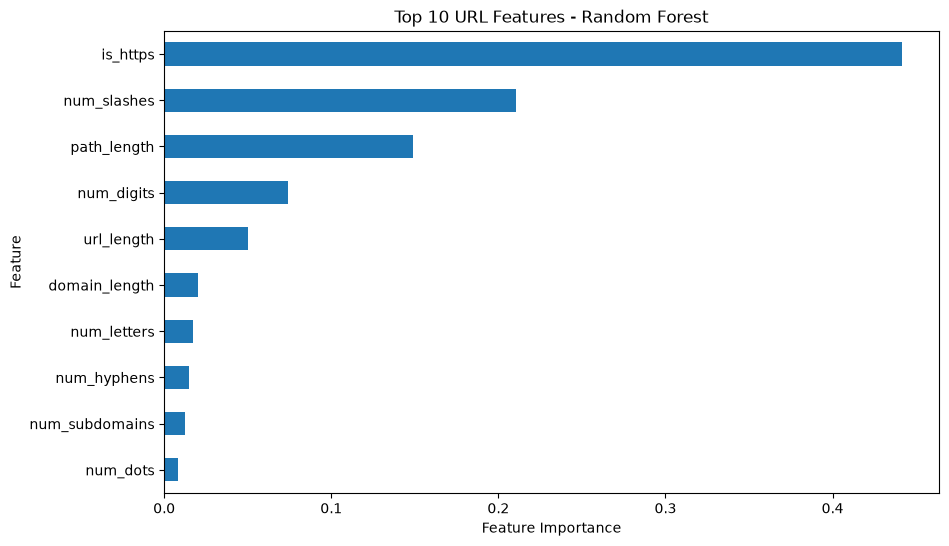

In [53]:
plt.figure(figsize=(10, 6))

url_feature_importance.head(10).sort_values().plot(
    kind="barh"
)

plt.title("Top 10 URL Features - Random Forest")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.show()

In [55]:
def extract_url_features_v2(url):

    features = {}

    # -------------------------
    # Basic URL features
    # -------------------------
    features["url_length"] = len(url)
    features["num_letters"] = sum(c.isalpha() for c in url)
    features["num_digits"] = sum(c.isdigit() for c in url)

    # -------------------------
    # Special characters
    # -------------------------
    features["num_dots"] = url.count(".")
    features["num_hyphens"] = url.count("-")
    features["num_underscores"] = url.count("_")
    features["num_slashes"] = url.count("/")
    features["num_question_marks"] = url.count("?")
    features["num_equal"] = url.count("=")
    features["num_at"] = url.count("@")
    features["num_ampersand"] = url.count("&")
    features["num_percent"] = url.count("%")
    features["num_colons"] = url.count(":")
    features["num_semicolons"] = url.count(";")

    # -------------------------
    # Suspicious // inside URL
    # -------------------------
    features["num_double_slashes"] = url.count("//")

    # -------------------------
    # Ratios
    # -------------------------
    if len(url) > 0:
        features["digit_ratio"] = (
            features["num_digits"] / len(url)
        )

        features["letter_ratio"] = (
            features["num_letters"] / len(url)
        )

        special_chars = sum(
            not c.isalnum() for c in url
        )

        features["special_char_ratio"] = (
            special_chars / len(url)
        )
    else:
        features["digit_ratio"] = 0
        features["letter_ratio"] = 0
        features["special_char_ratio"] = 0

    # -------------------------
    # HTTPS
    # -------------------------
    features["is_https"] = int(
        url.lower().startswith("https://")
    )

    # -------------------------
    # Parse URL
    # -------------------------
    parsed = urlparse(url)

    domain = parsed.netloc.split(":")[0]
    path = parsed.path
    query = parsed.query
    fragment = parsed.fragment

    # -------------------------
    # Domain features
    # -------------------------
    features["domain_length"] = len(domain)
    features["domain_dot_count"] = domain.count(".")
    features["domain_has_hyphen"] = int("-" in domain)

    features["domain_has_digits"] = int(
        any(c.isdigit() for c in domain)
    )

    # -------------------------
    # Path features
    # -------------------------
    features["path_length"] = len(path)

    features["num_path_segments"] = len(
        [x for x in path.split("/") if x]
    )

    # -------------------------
    # Query features
    # -------------------------
    features["query_length"] = len(query)

    features["query_parameter_count"] = (
        len(query.split("&"))
        if query else 0
    )

    # -------------------------
    # Fragment features
    # -------------------------
    features["fragment_length"] = len(fragment)

    features["has_fragment"] = int(
        bool(fragment)
    )

    # -------------------------
    # Subdomain features
    # -------------------------
    features["num_subdomains"] = max(
        0,
        len(domain.split(".")) - 2
    )

    # -------------------------
    # IP address
    # -------------------------
    features["has_ip"] = int(
        bool(
            re.search(
                r"^(?:\d{1,3}\.){3}\d{1,3}$",
                domain
            )
        )
    )

    # -------------------------
    # Suspicious keywords
    # -------------------------
    suspicious_keywords = [
        "login",
        "signin",
        "verify",
        "verification",
        "account",
        "update",
        "secure",
        "security",
        "password",
        "confirm",
        "bank",
        "paypal",
        "payment",
        "wallet",
        "credential",
        "authenticate"
    ]

    url_lower = url.lower()

    keyword_count = sum(
        keyword in url_lower
        for keyword in suspicious_keywords
    )

    features["suspicious_keyword_count"] = keyword_count

    features["has_suspicious_keyword"] = int(
        keyword_count > 0
    )

    return features

In [56]:
# Test V2

In [58]:
test_url = "https://example.com/login?id=123"

v2_features = extract_url_features_v2(test_url)

print(v2_features)
print("\nNumber of features:", len(v2_features))

{'url_length': 32, 'num_letters': 22, 'num_digits': 3, 'num_dots': 1, 'num_hyphens': 0, 'num_underscores': 0, 'num_slashes': 3, 'num_question_marks': 1, 'num_equal': 1, 'num_at': 0, 'num_ampersand': 0, 'num_percent': 0, 'num_colons': 1, 'num_semicolons': 0, 'num_double_slashes': 1, 'digit_ratio': 0.09375, 'letter_ratio': 0.6875, 'special_char_ratio': 0.21875, 'is_https': 1, 'domain_length': 11, 'domain_dot_count': 1, 'domain_has_hyphen': 0, 'domain_has_digits': 0, 'path_length': 6, 'num_path_segments': 1, 'query_length': 6, 'query_parameter_count': 1, 'fragment_length': 0, 'has_fragment': 0, 'num_subdomains': 0, 'has_ip': 0, 'suspicious_keyword_count': 1, 'has_suspicious_keyword': 1}

Number of features: 33


In [59]:
# Process All 235,370 URLs

In [60]:
url_features_v2 = df["URL"].apply(
    extract_url_features_v2
)

In [61]:
url_features_v2_df = pd.DataFrame(
    url_features_v2.tolist()
)

In [62]:
print("V2 feature shape:", url_features_v2_df.shape)

V2 feature shape: (235370, 33)


In [63]:
# Check the V2 Dataset

In [64]:
print(
    "Missing values:",
    url_features_v2_df.isnull().sum().sum()
)

Missing values: 0


In [65]:
print(
    "Data types:"
)

print(
    url_features_v2_df.dtypes.value_counts()
)

Data types:
int64      30
float64     3
Name: count, dtype: int64


In [66]:
url_features_v2_df.head()

,url_length,num_letters,num_digits,num_dots,num_hyphens,num_underscores,num_slashes,num_question_marks,num_equal,num_at,...,path_length,num_path_segments,query_length,query_parameter_count,fragment_length,has_fragment,num_subdomains,has_ip,suspicious_keyword_count,has_suspicious_keyword
0,32,27,0,2,0,0,2,0,0,0,...,0,0,0,0,0,0,1,0,1,1
1,24,18,0,2,1,0,2,0,0,0,...,0,0,0,0,0,0,1,0,0,0
2,30,24,0,3,0,0,2,0,0,0,...,0,0,0,0,0,0,2,0,0,0
3,27,22,0,2,0,0,2,0,0,0,...,0,0,0,0,0,0,1,0,0,0
4,34,29,0,2,0,0,2,0,0,0,...,0,0,0,0,0,0,1,0,0,0


In [67]:
# Create the Target

In [68]:
y_url

0         1
1         1
2         1
3         1
4         1
         ..
235790    1
235791    1
235792    1
235793    0
235794    1
Name: label, Length: 235370, dtype: int64

In [69]:
y_url_v2 = df["label"].copy()

In [70]:
print("Features:", url_features_v2_df.shape)
print("Target:", y_url_v2.shape)

Features: (235370, 33)
Target: (235370,)


In [71]:
# Train/Test Split

In [72]:
X_v2_train, X_v2_test, y_v2_train, y_v2_test = train_test_split(
    url_features_v2_df,
    y_url_v2,
    test_size=0.20,
    random_state=42,
    stratify=y_url_v2
)

print("Training:", X_v2_train.shape)
print("Testing :", X_v2_test.shape)

Training: (188296, 33)
Testing : (47074, 33)


In [73]:
# Train V2 Random Forest

In [74]:
url_rf_v2 = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

url_rf_v2.fit(
    X_v2_train,
    y_v2_train
)

print("V2 URL Random Forest trained!")

V2 URL Random Forest trained!


In [75]:
url_rf_v2_pred = url_rf_v2.predict(
    X_v2_test
)

In [76]:
# Evaluate V2

In [77]:
v2_accuracy = accuracy_score(
    y_v2_test,
    url_rf_v2_pred
)

v2_precision = precision_score(
    y_v2_test,
    url_rf_v2_pred,
    pos_label=0
)

v2_recall = recall_score(
    y_v2_test,
    url_rf_v2_pred,
    pos_label=0
)

v2_f1 = f1_score(
    y_v2_test,
    url_rf_v2_pred,
    pos_label=0
)

print("Accuracy:", v2_accuracy)
print("Phishing Precision:", v2_precision)
print("Phishing Recall:", v2_recall)
print("Phishing F1:", v2_f1)

Accuracy: 0.9957938564812848
Phishing Precision: 0.9987972336373659
Phishing Recall: 0.9913450059689614
Phishing F1: 0.9950571671076939


In [78]:
print(classification_report(
    y_v2_test,
    url_rf_v2_pred
))

              precision    recall  f1-score   support

           0       1.00      0.99      1.00     20104
           1       0.99      1.00      1.00     26970

    accuracy                           1.00     47074
   macro avg       1.00      1.00      1.00     47074
weighted avg       1.00      1.00      1.00     47074



In [79]:
# Compare V1 vs V2

In [80]:
url_comparison = pd.DataFrame({
    "Model": [
        "V1 Logistic Regression",
        "V1 Random Forest",
        "V2 Random Forest"
    ],
    "Accuracy": [
        url_accuracy,
        url_rf_accuracy,
        v2_accuracy
    ],
    "Phishing Precision": [
        url_precision,
        url_rf_precision,
        v2_precision
    ],
    "Phishing Recall": [
        url_recall,
        url_rf_recall,
        v2_recall
    ],
    "Phishing F1": [
        url_f1,
        url_rf_f1,
        v2_f1
    ]
})

url_comparison

,Model,Accuracy,Phishing Precision,Phishing Recall,Phishing F1
0,V1 Logistic Regression,0.993075,0.999344,0.984431,0.991831
1,V1 Random Forest,0.995645,0.998847,0.990947,0.994881
2,V2 Random Forest,0.995794,0.998797,0.991345,0.995057


In [81]:
# Analyze V2 Feature Importance

In [82]:
v2_feature_importance = pd.Series(
    url_rf_v2.feature_importances_,
    index=url_features_v2_df.columns
).sort_values(ascending=False)

print(v2_feature_importance.head(15))

is_https             0.406942
num_slashes          0.166396
path_length          0.140094
digit_ratio          0.043684
num_digits           0.042717
url_length           0.041386
domain_length        0.028128
num_path_segments    0.020418
letter_ratio         0.019176
domain_has_digits    0.018923
num_letters          0.015814
num_subdomains       0.011431
num_hyphens          0.010666
domain_dot_count     0.009417
num_dots             0.008372
dtype: float64


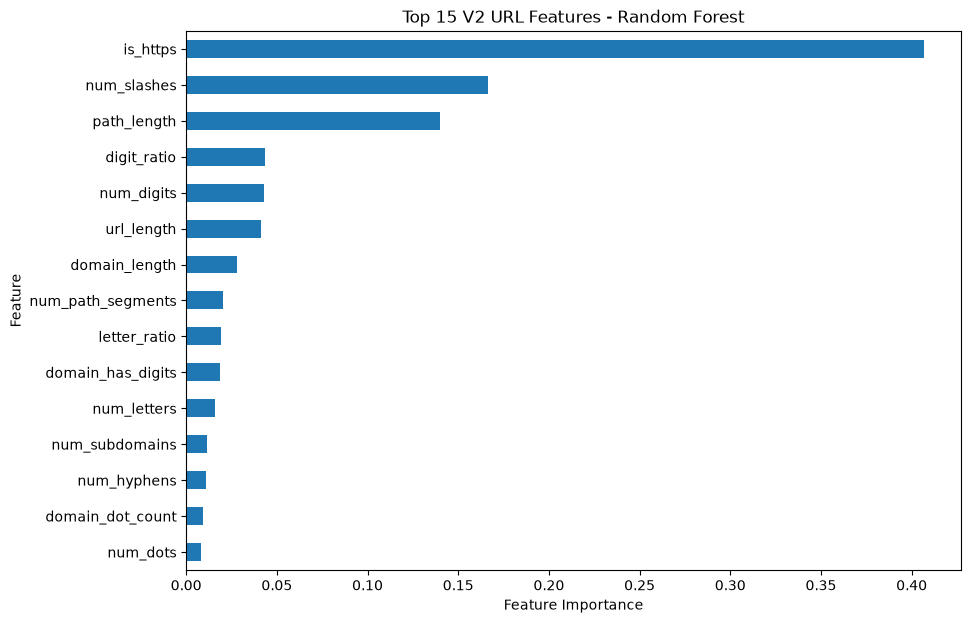

In [83]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))

v2_feature_importance.head(15).sort_values().plot(
    kind="barh"
)

plt.title("Top 15 V2 URL Features - Random Forest")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.show()

In [84]:
# Check V2 Confusion Matrix

In [86]:
from sklearn.metrics import confusion_matrix

In [87]:
cm_v2 = confusion_matrix(
    y_v2_test,
    url_rf_v2_pred
)

print(cm_v2)

[[19930   174]
 [   24 26946]]


In [88]:
tn, fp, fn, tp = cm_v2.ravel()

print("True Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives  :", tp)

True Negatives : 19930
False Positives: 174
False Negatives: 24
True Positives  : 26946


In [89]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import joblib

from urllib.parse import urlparse

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [90]:
# Save the V2 Model

In [91]:
import joblib

joblib.dump(
    url_rf_v2,
    "../models/url_phishing_random_forest_v2.pkl"
)

print("Model saved successfully!")

Model saved successfully!


In [92]:
joblib.dump(
    list(url_features_v2_df.columns),
    "../models/url_feature_names_v2.pkl"
)

print("Feature names saved successfully!")

Feature names saved successfully!


In [93]:
# Verify the files

In [94]:
import os

print(
    "Model:",
    os.path.exists(
        "../models/url_phishing_random_forest_v2.pkl"
    )
)

print(
    "Features:",
    os.path.exists(
        "../models/url_feature_names_v2.pkl"
    )
)

Model: True
Features: True


In [95]:
# Test Loading the Saved Model

In [96]:
loaded_model = joblib.load(
    "../models/url_phishing_random_forest_v2.pkl"
)

loaded_features = joblib.load(
    "../models/url_feature_names_v2.pkl"
)

print("Model loaded:", type(loaded_model))
print("Number of features:", len(loaded_features))

Model loaded: <class 'sklearn.ensemble._forest.RandomForestClassifier'>
Number of features: 33


In [98]:
# Test a New URL

In [99]:
def predict_url(url):

    features = extract_url_features_v2(url)

    feature_df = pd.DataFrame([features])

    prediction = loaded_model.predict(feature_df)[0]

    probability = loaded_model.predict_proba(
        feature_df
    )[0]

    return prediction, probability

In [100]:
test_url = "https://example.com/login?id=123"

prediction, probability = predict_url(test_url)

print("URL:", test_url)
print("Prediction:", prediction)
print("Probability:", probability)

URL: https://example.com/login?id=123
Prediction: 0
Probability: [1. 0.]


In [101]:
if prediction == 0:
    print("🔴 Prediction: Phishing")
else:
    print("🟢 Prediction: Legitimate")

🔴 Prediction: Phishing


In [102]:
test_urls = [
    "https://example.com",
    "https://example.com/login",
    "http://192.168.1.10/login",
    "https://secure-example.com/account/verify",
    "http://paypal-login-example.com/verify"
]

In [103]:
for url in test_urls:

    prediction, probability = predict_url(url)

    result = (
        "🔴 Phishing"
        if prediction == 0
        else "🟢 Legitimate"
    )

    print("\nURL:", url)
    print("Result:", result)
    print("Probabilities:", probability)


URL: https://example.com
Result: 🔴 Phishing
Probabilities: [1. 0.]

URL: https://example.com/login
Result: 🔴 Phishing
Probabilities: [1. 0.]

URL: http://192.168.1.10/login
Result: 🔴 Phishing
Probabilities: [0.995 0.005]

URL: https://secure-example.com/account/verify
Result: 🔴 Phishing
Probabilities: [1. 0.]

URL: http://paypal-login-example.com/verify
Result: 🔴 Phishing
Probabilities: [1. 0.]


In [104]:
# Streamlit Web Application

In [105]:
"""
                     USER
                   │
                   ▼
            Enter URL
                   │
                   ▼
        URL Feature Extractor
                   │
                   ▼
          33 URL Features
                   │
                   ▼
       Random Forest Model
                   │
                   ▼
       ┌───────────┴───────────┐
       ▼                       ▼
  🔴 Phishing             🟢 Legitimate
       │                       │
       └──────── Probability ──┘
    """

'\n                     USER\n                   │\n                   ▼\n            Enter URL\n                   │\n                   ▼\n        URL Feature Extractor\n                   │\n                   ▼\n          33 URL Features\n                   │\n                   ▼\n       Random Forest Model\n                   │\n                   ▼\n       ┌───────────┴───────────┐\n       ▼                       ▼\n  🔴 Phishing             🟢 Legitimate\n       │                       │\n       └──────── Probability ──┘\n    '

In [107]:
# 3 Test Known Dataset URLs

In [108]:
sample_urls = df["URL"].sample(
    10,
    random_state=42
).tolist()

In [109]:
for url in sample_urls:

    prediction, probability = predict_url(url)

    result = (
        "🔴 Phishing"
        if prediction == 0
        else "🟢 Legitimate"
    )

    print("\nURL:", url)
    print("Prediction:", result)
    print("Probability:", probability)


URL: http://www.s107008.hostde20.fornex.host
Prediction: 🔴 Phishing
Probability: [1. 0.]

URL: https://www.espresso4you.nl
Prediction: 🟢 Legitimate
Probability: [0.01376001 0.98623999]

URL: https://www.mazzios.com
Prediction: 🟢 Legitimate
Probability: [0.00325084 0.99674916]

URL: http://www.digitalkhulna.com
Prediction: 🔴 Phishing
Probability: [1. 0.]

URL: http://www.pathregretforce.com
Prediction: 🔴 Phishing
Probability: [1. 0.]

URL: https://www.jmrlsi.co.jp
Prediction: 🟢 Legitimate
Probability: [0.00200853 0.99799147]

URL: https://www.harborcountry-news.com
Prediction: 🟢 Legitimate
Probability: [0.02838237 0.97161763]

URL: http://www.baajaa.com
Prediction: 🔴 Phishing
Probability: [1. 0.]

URL: http://www.apat.org
Prediction: 🔴 Phishing
Probability: [1. 0.]

URL: https://www.omhof.org
Prediction: 🟢 Legitimate
Probability: [0.00273402 0.99726598]


In [110]:
# Compare Prediction With the Actual Label

In [111]:
sample_df = df[["URL", "label"]].sample(
    20,
    random_state=42
)

for _, row in sample_df.iterrows():

    prediction, probability = predict_url(row["URL"])

    actual = (
        "Phishing"
        if row["label"] == 0
        else "Legitimate"
    )

    predicted = (
        "Phishing"
        if prediction == 0
        else "Legitimate"
    )

    print(
        f"\nURL: {row['URL']}"
    )

    print(
        f"Actual: {actual}"
    )

    print(
        f"Predicted: {predicted}"
    )

    print(
        f"Probability: {probability}"
    )


URL: http://www.s107008.hostde20.fornex.host
Actual: Phishing
Predicted: Phishing
Probability: [1. 0.]

URL: https://www.espresso4you.nl
Actual: Legitimate
Predicted: Legitimate
Probability: [0.01376001 0.98623999]

URL: https://www.mazzios.com
Actual: Legitimate
Predicted: Legitimate
Probability: [0.00325084 0.99674916]

URL: http://www.digitalkhulna.com
Actual: Phishing
Predicted: Phishing
Probability: [1. 0.]

URL: http://www.pathregretforce.com
Actual: Phishing
Predicted: Phishing
Probability: [1. 0.]

URL: https://www.jmrlsi.co.jp
Actual: Legitimate
Predicted: Legitimate
Probability: [0.00200853 0.99799147]

URL: https://www.harborcountry-news.com
Actual: Legitimate
Predicted: Legitimate
Probability: [0.02838237 0.97161763]

URL: http://www.baajaa.com
Actual: Phishing
Predicted: Phishing
Probability: [1. 0.]

URL: http://www.apat.org
Actual: Phishing
Predicted: Phishing
Probability: [1. 0.]

URL: https://www.omhof.org
Actual: Legitimate
Predicted: Legitimate
Probability: [0.00273

In [112]:
# Build the Streamlit Application 🚀

In [113]:
"""
   malicious-website-detection/
│
├── app/
│   └── app.py
│
├── data/
│   └── PhiUSIIL_Phishing_URL_Dataset.csv
│
├── models/
│   ├── url_phishing_random_forest_v2.pkl
│   └── url_feature_names_v2.pkl
│
├── notebooks/
│   ├── ...
│   └── 07_url_feature_engineering.ipynb
│
└── venv/
    """

'\n   malicious-website-detection/\n│\n├── app/\n│   └── app.py\n│\n├── data/\n│   └── PhiUSIIL_Phishing_URL_Dataset.csv\n│\n├── models/\n│   ├── url_phishing_random_forest_v2.pkl\n│   └── url_feature_names_v2.pkl\n│\n├── notebooks/\n│   ├── ...\n│   └── 07_url_feature_engineering.ipynb\n│\n└── venv/\n    '

In [114]:
# Save the Model

In [115]:
import os

print(
    os.path.exists(
        "../models/url_phishing_random_forest_v2.pkl"
    )
)

print(
    os.path.exists(
        "../models/url_feature_names_v2.pkl"
    )
)

True
True
